In [2]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader
import warnings
warnings.filterwarnings('ignore')

# ==================== Global configuration ====================
# Data paths
NCAR_PATH = '..Data-NCAR/data01/daily/'
TYPHOON_FILE = './typhoon_output/landfall_typhoons_tracks.csv'
MJO_FILE = './ERA5 MJO (1950-2024).csv'
CHINA_SHAPEFILE = './shapefiles/china.shp'
NINE_LINE_SHAPEFILE = './shapefiles/china_nine_dotted_line.shp'

# Output directory for composite data
COMPOSITE_DIR = './mjo_composites/'
os.makedirs(COMPOSITE_DIR, exist_ok=True)

# Year range
YEARS = np.arange(1960, 2025)  # 1960-2024

# Variable information: (output name, variable name, level, used for plotting)
VAR_INFO = [
    ('uwnd200', 'uwnd', 200, True),
    ('uwnd850', 'uwnd', 850, True),
    ('slp', 'slp', None, True),
    ('hgt500', 'hgt', 500, True),
    ('uwnd500', 'uwnd', 500, False),  # for 500 hPa wind vectors
    ('vwnd500', 'vwnd', 500, False),  # for 500 hPa wind vectors
]

# Phase group mapping
PHASE_GROUPS = {
    (1,2): 'P1-2',
    (3,4): 'P3-4',
    (5,6): 'P5-6',
    (7,8): 'P7-8'
}
GROUP_ORDER = ['P1-2', 'P3-4', 'P5-6', 'P7-8']
GROUP_LABELS = ['Phases 1-2', 'Phases 3-4', 'Phases 5-6', 'Phases 7-8']

# Plotting domain
DEFAULT_LON_SLICE = slice(0, 180)
DEFAULT_LAT_SLICE = slice(60, 0)   # lat decreases from 90 to -90

# ==================== Helper functions ====================
def print_separator(title):
    """Print separator and title"""
    print("\n" + "="*60)
    print(title)
    print("="*60)

def get_file_list(varname, years, base_path):
    """Get a list of existing files for a given variable across years"""
    files = []
    for yr in years:
        fpath = os.path.join(base_path, f"{varname}.{yr}.nc")
        if os.path.exists(fpath):
            files.append(fpath)
        else:
            print(f"Warning: file not found {fpath}")
    return files

def preprocess(ds, level=None, drop_vars=['time_bnds']):
    """Preprocessing function: select level, drop inconsistent variables"""
    if level is not None:
        ds = ds.sel(level=level, method='nearest')
    # Drop variables that may cause merge failures (some files have them, some don't)
    ds = ds.drop_vars(drop_vars, errors='ignore')
    return ds

# ==================== Data reading and date filtering ====================
print_separator("Step 1: Read typhoon data, extract all typhoon-active dates in June-October")
ty_df = pd.read_csv(TYPHOON_FILE, parse_dates=['TIME'])
print(f"Original typhoon record count: {len(ty_df)}")
# Extract date part, unique
ty_dates = pd.Series(ty_df['TIME'].dt.floor('D').unique())
print(f"Total unique typhoon-active days (all months): {len(ty_dates)}")
# Filter June-October
ty_dates_6_10 = ty_dates[ty_dates.dt.month.isin([6,7,8,9,10])]
print(f"Typhoon-active days in June-October: {len(ty_dates_6_10)}")
print("First 5 dates:", ty_dates_6_10.head().tolist())

print_separator("Step 2: Read MJO data, filter 1960-2024 & amplitude>=1, and assign phase groups")
mjo_df = pd.read_csv(MJO_FILE, parse_dates=['date'])
print(f"Original MJO records: {len(mjo_df)}")
mjo_df = mjo_df[(mjo_df['date'].dt.year >= 1960) & (mjo_df['date'].dt.year <= 2024)]
print(f"Records after year filter: {len(mjo_df)}")
mjo_df = mjo_df[mjo_df['amplitude'] >= 1].copy()
print(f"Records with amplitude >= 1: {len(mjo_df)}")

def phase_group(phase):
    for (low, high), label in PHASE_GROUPS.items():
        if low <= phase <= high:
            return label
    return None

mjo_df['group'] = mjo_df['phase'].apply(phase_group)
mjo_df = mjo_df.dropna(subset=['group'])
print("Records per phase group:")
print(mjo_df['group'].value_counts())

# Extract dates and groups (truncate time part)
mjo_dates = mjo_df[['date', 'group']].copy()
mjo_dates['date'] = pd.to_datetime(mjo_dates['date'].dt.date)

print_separator("Step 3: Intersection of typhoon-active dates & MJO>=1 dates (Jun-Oct)")
common = pd.merge(pd.DataFrame({'date': ty_dates_6_10}), mjo_dates, on='date', how='inner')
print(f"Total intersection days: {len(common)}")

# Separate dates by group
group_dates = {}
for group in GROUP_ORDER:
    dates = common[common['group']==group]['date'].tolist()
    group_dates[group] = dates
    print(f"{group}: {len(dates)} days")
    if len(dates) > 0:
        print(f"  Example dates: {dates[:3]}")

# ==================== Read reanalysis data and compute climatological mean/std ====================
print_separator("Step 4: Read reanalysis data, compute climatological mean and standard deviation (all years June-October)")

clim_dict = {}

for out_name, varname, level, _ in VAR_INFO:
    print(f"\nProcessing variable: {out_name} (raw: {varname}, level: {level})")
    files = get_file_list(varname, YEARS, NCAR_PATH)
    if not files:
        raise ValueError(f"No files found for {varname}")
    
    def _preprocess(ds, lvl=level):
        return preprocess(ds, level=lvl, drop_vars=['time_bnds'])
    
    print(f"  Opening {len(files)} files...")
    # --- FIX: Use a 'with' context manager to auto-close the dataset ---
    with xr.open_mfdataset(files, combine='nested', concat_dim='time',
                           preprocess=_preprocess, parallel=True,
                           chunks={'time': 365}) as ds:
        print("  Dataset overview:")
        print(ds)
        
        ds_6_10 = ds.sel(time=ds.time.dt.month.isin([6,7,8,9,10]))
        print(f"  Total time steps in June-October: {len(ds_6_10.time)}")
        
        print("  Computing climatological mean...")
        clim_mean = ds_6_10.mean(dim='time').compute()
        print(f"  Climatological mean shape: {clim_mean[varname].shape}")
        
        print("  Computing climatological standard deviation (ddof=1)...")
        clim_std = ds_6_10.std(dim='time', ddof=1).compute()
        print(f"  Climatological std shape: {clim_std[varname].shape}")
        
        clim_std = xr.where(clim_std == 0, np.nan, clim_std)
        
        clim_dict[out_name] = (clim_mean, clim_std)
    # Dataset is automatically closed when exiting the 'with' block

# ==================== Compute composite standardized anomaly for each phase group and save ====================
print_separator("Step 5: Compute composite standardized anomaly for each phase group and save to NetCDF files")

for out_name, varname, level, _ in VAR_INFO:
    print(f"\nComputing composite anomaly for variable {out_name}...")
    files = get_file_list(varname, YEARS, NCAR_PATH)
    clim_mean, clim_std = clim_dict[out_name]
    ref_da = clim_mean[varname]
    
    def _preprocess(ds, lvl=level):
        return preprocess(ds, level=lvl, drop_vars=['time_bnds'])
    
    # --- FIX: Use a 'with' context manager ---
    with xr.open_mfdataset(files, combine='nested', concat_dim='time',
                           preprocess=_preprocess, parallel=True,
                           chunks={'time': 365}) as ds_all:
        
        group_arrays = {}
        for group in GROUP_ORDER:
            dates = group_dates[group]
            if len(dates) == 0:
                print(f"  Group {group}: no dates, saving as NaN array")
                nan_arr = xr.full_like(ref_da, np.nan)
                group_arrays[group] = nan_arr
            else:
                print(f"  Group {group}: selecting {len(dates)} days")
                ds_group = ds_all.sel(time=dates)
                anom = (ds_group - clim_mean) / clim_std
                comp = anom.mean(dim='time').compute()
                group_arrays[group] = comp[varname]
                print(f"    Composite anomaly shape: {group_arrays[group].shape}")
                print(f"    Value range: [{group_arrays[group].min().values:.3f}, {group_arrays[group].max().values:.3f}]")
    
    # Combine into a Dataset and save
    ds_out = xr.Dataset(
        data_vars={group: group_arrays[group] for group in GROUP_ORDER},
        coords=group_arrays[GROUP_ORDER[0]].coords,
        attrs={
            'description': f'MJO composite standardized anomaly for {out_name}',
            'units': clim_mean[varname].attrs.get('units', 'unknown'),
            'long_name': clim_mean[varname].attrs.get('long_name', out_name)
        }
    )
    out_file = os.path.join(COMPOSITE_DIR, f"{out_name}_composite.nc")
    ds_out.to_netcdf(out_file)
    print(f"Saved: {out_file}")

# ==================== Plotting function (unchanged) ====================
# ... (the plotting function plot_mjo_composites_from_files remains exactly as in the original code)


Step 1: Read typhoon data, extract all typhoon-active dates in June-October
Original typhoon record count: 16526
Total unique typhoon-active days (all months): 3724
Typhoon-active days in June-October: 3504
First 5 dates: [Timestamp('1960-06-02 00:00:00'), Timestamp('1960-06-03 00:00:00'), Timestamp('1960-06-04 00:00:00'), Timestamp('1960-06-05 00:00:00'), Timestamp('1960-06-06 00:00:00')]

Step 2: Read MJO data, filter 1960-2024 & amplitude>=1, and assign phase groups
Original MJO records: 27394
Records after year filter: 23742
Records with amplitude >= 1: 14550
Records per phase group:
P5-6    3927
P1-2    3748
P7-8    3462
P3-4    3413
Name: group, dtype: int64

Step 3: Intersection of typhoon-active dates & MJO>=1 dates (Jun-Oct)
Total intersection days: 1969
P1-2: 343 days
  Example dates: [Timestamp('1960-06-08 00:00:00'), Timestamp('1960-07-17 00:00:00'), Timestamp('1960-07-18 00:00:00')]
P3-4: 285 days
  Example dates: [Timestamp('1960-08-01 00:00:00'), Timestamp('1961-06-26 0

In [18]:
def plot_mjo_composites_from_files(data_dir, var_config, lon_slice, lat_slice,
                                   save_path=None, show=True,
                                   ncols=2,
                                   figsize=None,
                                   outer_wspace=0.2, outer_hspace=0.2,
                                   inner_wspace=0.1, inner_hspace=0.1,
                                   xticks=None, yticks=None,
                                   tick_labelsize=10,
                                   title_fontsize=12,
                                   suptitle_fontsize=16,
                                   sig_file=None):   # new parameter

    import matplotlib.ticker as mticker
    import matplotlib.gridspec as gridspec
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.io.shapereader import Reader
    import numpy as np
    import xarray as xr
    import os

    # Constants (phase group order and labels)
    GROUP_ORDER = ['1-2', '3-4', '5-6', '7-8']
    GROUP_LABELS = ['Phase 1-2', 'Phase 3-4', 'Phase 5-6', 'Phase 7-8']

    # China shapefile paths (adjust as needed)
    CHINA_SHAPEFILE = './shapefiles/china.shp'
    NINE_LINE_SHAPEFILE = './shapefiles/china_nine_dotted_line.shp'

    # Helper: map short variable name to base name in files
    def var_to_base(v):
        mapping = {
            'uwnd200': 'uwnd_200',
            'uwnd850': 'uwnd_850',
            'uwnd500': 'uwnd_500',
            'vwnd500': 'vwnd_500',
            'hgt500': 'hgt_500',
            'slp': 'slp'
        }
        return mapping.get(v, v)

    # ---------- 1. Read data ----------
    if sig_file is not None and os.path.exists(sig_file):
        print(f"Using significance file: {sig_file}")
        ds_sig = xr.open_dataset(sig_file)
        # Build anomaly and significance dictionaries
        composites = {group: {} for group in GROUP_ORDER}
        sig_masks = {group: {} for group in GROUP_ORDER}
        for var in ds_sig.data_vars:
            parts = var.split('_')
            if len(parts) < 3:
                continue
            suffix = parts[-1]          # anom or sig
            group = parts[-2]            # group name like '1-2'
            if group not in GROUP_ORDER:
                continue
            base = '_'.join(parts[:-2])  # base variable name, e.g., 'uwnd_200'
            if suffix == 'anom':
                composites[group][base] = ds_sig[var]
            elif suffix == 'sig':
                sig_masks[group][base] = ds_sig[var]
        ds_sig.close()
    else:
        # Traditional method: read individual variable composite files from data_dir
        composites = {group: {} for group in GROUP_ORDER}
        sig_masks = None   # no significance
        # Collect all variable names to read (including wind components)
        all_vars = set()
        for vc in var_config:
            all_vars.add(vc['var'])
            if vc.get('plot_vector', False):
                all_vars.add(vc.get('u_var'))
                all_vars.add(vc.get('v_var'))
        all_vars = [v for v in all_vars if v is not None]

        for var in all_vars:
            file_path = os.path.join(data_dir, f"{var}_composite.nc")
            if not os.path.exists(file_path):
                print(f"Warning: file {file_path} does not exist, skipping variable {var}")
                continue
            ds = xr.open_dataset(file_path)
            for group in GROUP_ORDER:
                if group in ds.data_vars:
                    composites[group][var] = ds[group]
                else:
                    # If missing, fill with NaN
                    ref_coords = ds[GROUP_ORDER[0]].coords if GROUP_ORDER[0] in ds.data_vars else None
                    if ref_coords is not None:
                        composites[group][var] = xr.full_like(ref_coords['var'], np.nan)
                    else:
                        composites[group][var] = None
            ds.close()

    # ---------- 2. Create figure ----------
    nvars = len(var_config)
    nrows = (nvars + ncols - 1) // ncols
    if figsize is None:
        figsize = (32 * ncols // 2, 16 * nrows // 2)

    fig = plt.figure(figsize=figsize)
    outer = gridspec.GridSpec(nrows, ncols, figure=fig,
                              wspace=outer_wspace, hspace=outer_hspace,
                              top=0.92, bottom=0.08)

    last_cf = None

    # ---------- 3. Loop over each variable ----------
    for idx, var_cfg in enumerate(var_config):
        i = idx // ncols
        j = idx % ncols

        var_name = var_cfg['var']
        title = var_cfg.get('title', var_name)
        levels = var_cfg.get('levels', np.arange(-3, 3.1, 0.5))
        cmap = var_cfg.get('cmap', plt.cm.RdBu_r)
        plot_vector = var_cfg.get('plot_vector', False)
        u_var = var_cfg.get('u_var', None)
        v_var = var_cfg.get('v_var', None)

        inner = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[i, j],
                                                  wspace=inner_wspace, hspace=inner_hspace)

        for k, group in enumerate(GROUP_ORDER):
            ax = fig.add_subplot(inner[k // 2, k % 2], projection=ccrs.PlateCarree())

            # Get anomaly field
            base = var_to_base(var_name)
            comp = composites[group].get(base, None)

            if comp is None:
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                        ha='center', va='center', fontsize=14)
            else:
                # Select region
                comp_region = comp.sel(lat=lat_slice, lon=lon_slice)
                lon = comp_region.lon.values
                lat = comp_region.lat.values

                # Plot filled contours
                cf = ax.contourf(lon, lat, comp_region, levels=levels,
                                 cmap=cmap, extend='both',
                                 transform=ccrs.PlateCarree())
                last_cf = cf

                # Overlay significance dots (white)
                if sig_masks is not None:
                    sig = sig_masks[group].get(base, None)
                    if sig is not None:
                        sig_region = sig.sel(lat=lat_slice, lon=lon_slice)
                        lon2d, lat2d = np.meshgrid(sig_region.lon, sig_region.lat)
                        ax.scatter(lon2d[sig_region==1], lat2d[sig_region==1],
                                   s=10, c='white', marker='.', transform=ccrs.PlateCarree(),
                                   alpha=0.8, linewidths=0)

                # Plot wind vectors (with significance filtering)
                if plot_vector and u_var is not None and v_var is not None:
                    u_base = var_to_base(u_var)
                    v_base = var_to_base(v_var)
                    u_comp = composites[group].get(u_base, None)
                    v_comp = composites[group].get(v_base, None)
                    if u_comp is not None and v_comp is not None:
                        u_region = u_comp.sel(lat=lat_slice, lon=lon_slice)
                        v_region = v_comp.sel(lat=lat_slice, lon=lon_slice)

                        # Get significance masks
                        if sig_masks is not None:
                            u_sig = sig_masks[group].get(u_base, None)
                            v_sig = sig_masks[group].get(v_base, None)
                            if u_sig is not None and v_sig is not None:
                                u_sig_region = u_sig.sel(lat=lat_slice, lon=lon_slice)
                                v_sig_region = v_sig.sel(lat=lat_slice, lon=lon_slice)
                                # Combined mask: keep if either u or v is significant
                                mask = (u_sig_region == 1) | (v_sig_region == 1)
                                u_region = u_region.where(mask)
                                v_region = v_region.where(mask)

                        # Subsampling for plotting
                        stride = 3  # adjust as needed
                        lon_subs = u_region.lon[::stride].values
                        lat_subs = u_region.lat[::stride].values
                        u_subs = u_region[::stride, ::stride].values
                        v_subs = v_region[::stride, ::stride].values
                        ax.quiver(lon_subs, lat_subs, u_subs, v_subs,
                                  transform=ccrs.PlateCarree(),
                                  scale=15,
                                  width=0.003,
                                  headwidth=4,
                                  headlength=5,
                                  headaxislength=5,
                                  pivot='middle',
                                  color='black',
                                  alpha=0.9,
                                  linewidths=0.3,
                                  edgecolors='black')

                # Add map features
                try:
                    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
                    ax.add_geometries(Reader(CHINA_SHAPEFILE).geometries(),
                                      ccrs.PlateCarree(), facecolor='none',
                                      linewidth=0.6, edgecolor='black')
                    ax.add_geometries(Reader(NINE_LINE_SHAPEFILE).geometries(),
                                      ccrs.PlateCarree(), facecolor='none',
                                      linewidth=0.6, edgecolor='black')
                except Exception as e:
                    print(f"Failed to add China boundary: {e}")

            # Set map extent (executed regardless of data availability)
            ax.set_extent([lon_slice.start, lon_slice.stop, lat_slice.stop, lat_slice.start],
                          crs=ccrs.PlateCarree())
            # Grid lines
            gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                              linewidth=0.5, color='gray', alpha=0.5)
            gl.top_labels = False
            gl.right_labels = False

            row_inner = k // 2
            col_inner = k % 2
            # Key modification: control label visibility based on global row/column
            gl.bottom_labels = (i == nrows - 1) and (row_inner == 1)
            gl.left_labels   = (j == 0) and (col_inner == 0)

            if xticks is not None:
                gl.xlocator = mticker.FixedLocator(xticks)
            if yticks is not None:
                gl.ylocator = mticker.FixedLocator(yticks)

            gl.xlabel_style = {'size': tick_labelsize}
            gl.ylabel_style = {'size': tick_labelsize}

            ax.set_title(GROUP_LABELS[k], fontsize=title_fontsize)

        # Add variable title
        pos = outer[i, j].get_position(fig)
        fig.text(pos.x0 + pos.width/2, pos.y0 + pos.height + 0.01,
                 title, ha='center', va='bottom', fontsize=suptitle_fontsize, fontweight='bold')

    # Add colorbar
    if last_cf is not None:
        cbar_ax = fig.add_axes([0.2, 0.055, 0.6, 0.010])
        cbar = fig.colorbar(last_cf, cax=cbar_ax, orientation='horizontal', extend='both')
        cbar.ax.tick_params(labelsize=tick_labelsize)

    # Save or show
    if save_path:
        fname = f"9all_{save_path}_combined.png"
        plt.savefig(fname, dpi=600, bbox_inches='tight')
        print(f"Saved: {fname}")
    if show:
        plt.show()
    plt.close()

Using significance file: ../mjo_phase_composites_sig.nc
Saved: 9all_MJO_composite_combined.png


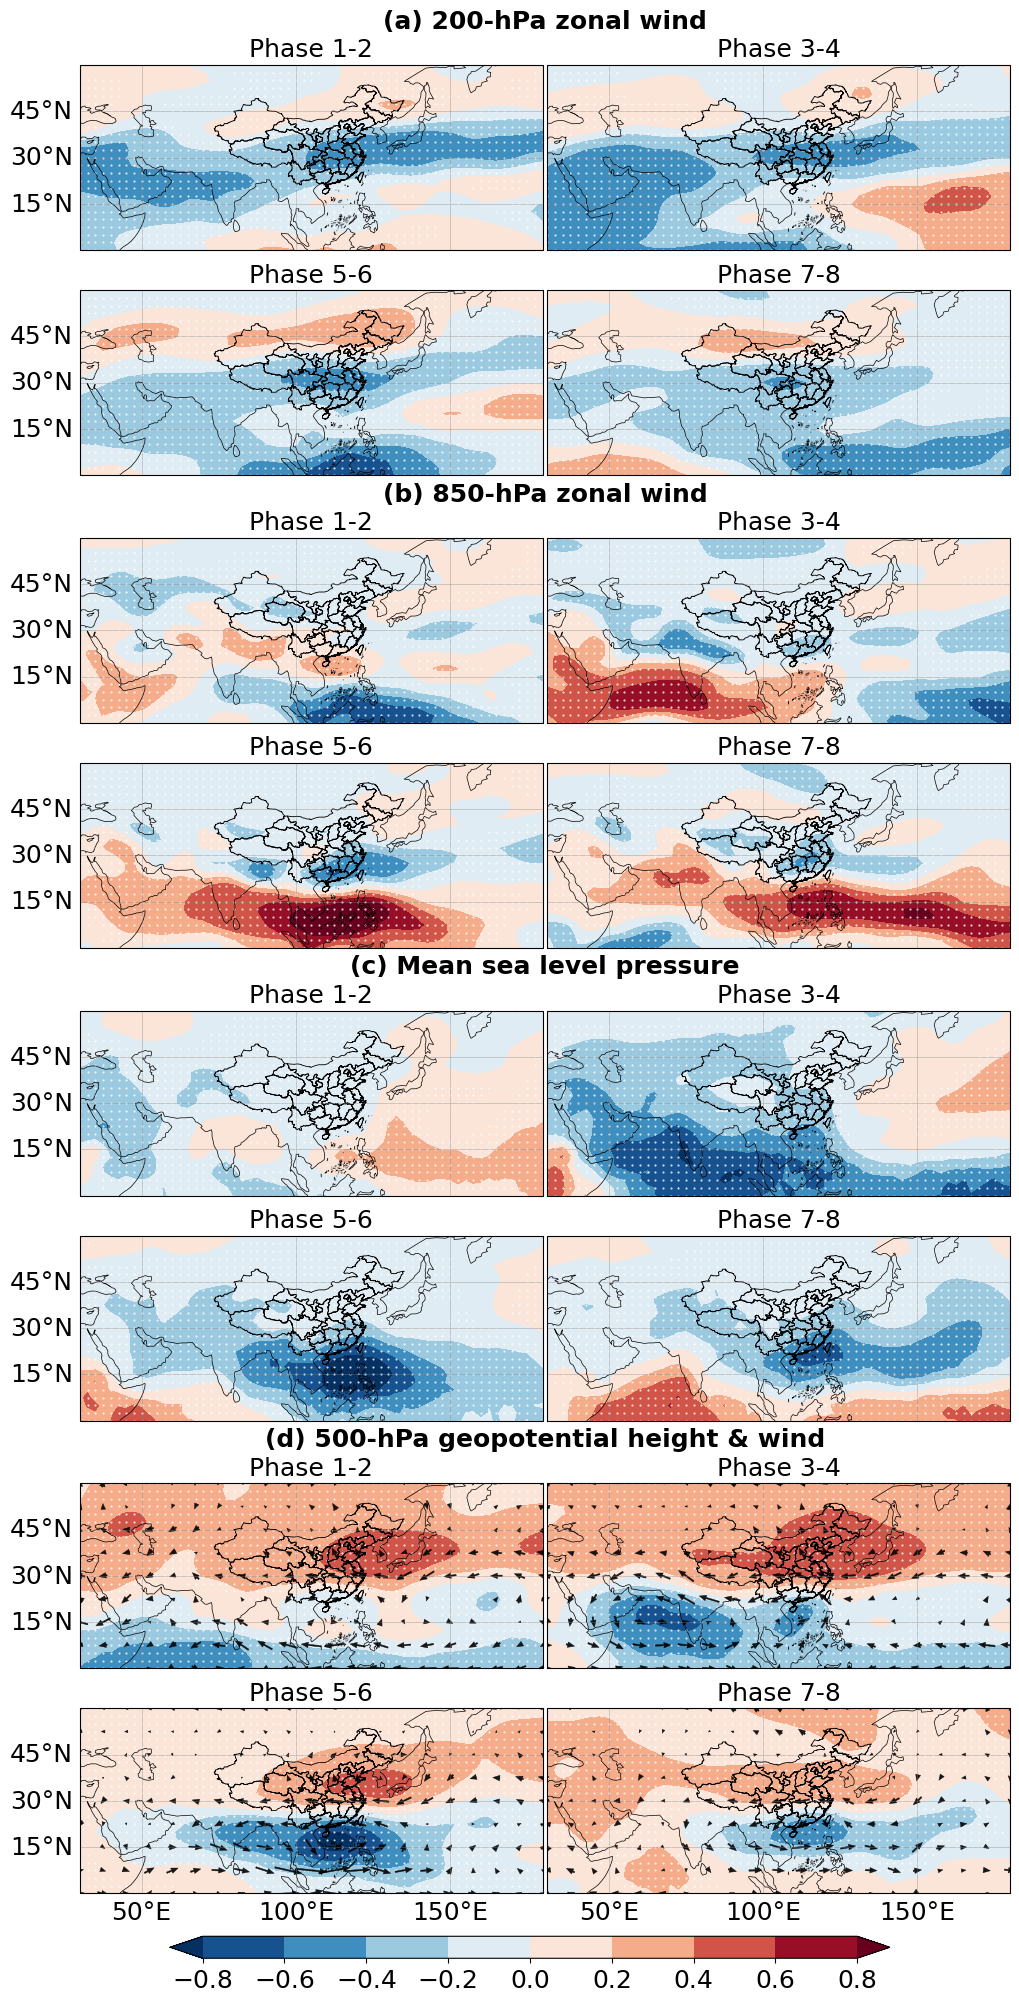

In [17]:
var_configs = [
    {
        'var': 'uwnd200',
        'title': '(a) 200-hPa zonal wind',
        'levels': np.arange(-0.8, 1, 0.2),
        'cmap': plt.cm.RdBu_r,
        'plot_vector': False
    },
    {
        'var': 'uwnd850',
        'title': '(b) 850-hPa zonal wind',
        'levels': np.arange(-0.8, 1, 0.2),
        'cmap': plt.cm.RdBu_r,
        'plot_vector': False
    },
    {
        'var': 'slp',
        'title': '(c) Mean sea level pressure',
        'levels': np.arange(-0.8, 1, 0.2),
        'cmap': plt.cm.RdBu_r,
        'plot_vector': False
    },
    {
        'var': 'hgt500',
        'title': '(d) 500-hPa geopotential height & wind',
        'levels': np.arange(-0.8, 1, 0.2),
        'cmap': plt.cm.RdBu_r,
        'plot_vector': True,
        'u_var': 'uwnd500',
        'v_var': 'vwnd500'
    }
]

 
DEFAULT_LON_SLICE = slice(30, 180)
DEFAULT_LAT_SLICE = slice(60, 0)   # lat从90到-90递减

 
SIG_FILE = './mjo_phase_composites_sig.nc'
 

plot_mjo_composites_from_files(
    data_dir=None,                     
    var_config=var_configs,
    lon_slice=DEFAULT_LON_SLICE,
    lat_slice=DEFAULT_LAT_SLICE,
    save_path='MJO_composite',
    show=True,
    ncols=1,                            
    figsize=(12, 22),             
    outer_wspace=0.1, outer_hspace=0.1,
    inner_wspace=0.01, inner_hspace=0.1,
    xticks=np.arange(0, 181, 50),
    yticks=np.arange(0, 56, 15),
    tick_labelsize=18,
    title_fontsize=18,
    suptitle_fontsize=18,
    sig_file=SIG_FILE                  
)

 